In [4]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

# IMPORT DATA



In [5]:
data = pd.read_csv('scdata.csv')
data.head()

,employee_id,name,department,salary,hire_date,performance_score,is_manager
0,EMP-0311,ADI Prasetyo S.E.,Ops,2291834.0,12/11/2022,99.0,Staff
1,EMP-0391,Made Wijaya,IT,6203171.0,04-25-2021,94.0,Staff
2,EMP-0007,REZA Pratama Putra M.T.,Marketing,11158426.0,09-11-2023,79.0,No
3,EMP-0185,ADI Rahayu,Marketing Dept,7553074.0,2018-07-08,74.0,FALSE
4,EMP-0079,Dr. Agus Mega Nugroho S.T.,Mkt Div,8183522.0,2020-08-22,90.0,0


# 1. EKSPLORASI DATA DAN TIPE DATA

In [6]:
# a) Fungsi untuk membaca CSV dan menampilkan informasi dasar dataset

def load_dataset(path):
    df = pd.read_csv(path)
    print('Shape dataset:', df.shape)
    print('\nKolom dataset:')
    print(df.columns.tolist())
    print('\nTipe data tiap kolom (method 1: dtypes):')
    print(df.dtypes)
    print('\nTipe data tiap kolom (method 2: apply dtype):')
    print(df.apply(lambda col: col.dtype))
    print('\nTipe data tiap kolom (method 3: sample Python type):')
    sample_types = {
        col: type(df[col].dropna().iloc[0]).__name__ if not df[col].dropna().empty else 'empty'
        for col in df.columns
    }
    print(sample_types)
    return df

# Load data
file_path = 'scdata.csv'
data = load_dataset(file_path)

Shape dataset: (525, 7)

Kolom dataset:
['employee_id', 'name', 'department', 'salary', 'hire_date', 'performance_score', 'is_manager']

Tipe data tiap kolom (method 1: dtypes):
employee_id           object
name                  object
department            object
salary               float64
hire_date             object
performance_score    float64
is_manager            object
dtype: object

Tipe data tiap kolom (method 2: apply dtype):
employee_id           object
name                  object
department            object
salary               float64
hire_date             object
performance_score    float64
is_manager            object
dtype: object

Tipe data tiap kolom (method 3: sample Python type):
{'employee_id': 'str', 'name': 'str', 'department': 'str', 'salary': 'float64', 'hire_date': 'str', 'performance_score': 'float64', 'is_manager': 'str'}



Jumlah missing values per kolom:
employee_id          12
name                 29
department           16
salary               27
hire_date            19
performance_score    12
is_manager           16
dtype: int64

Persentase missing values per kolom:
employee_id          2.29
name                 5.52
department           3.05
salary               5.14
hire_date            3.62
performance_score    2.29
is_manager           3.05
dtype: float64


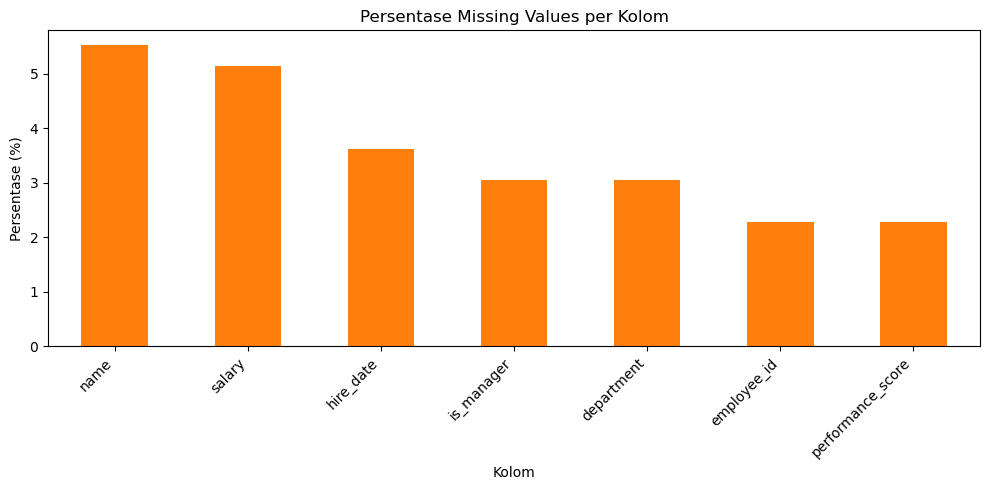

In [7]:
# b) Identifikasi dan hitung missing values per kolom
missing_count = data.isnull().sum()
missing_percent = data.isnull().mean() * 100
print('\nJumlah missing values per kolom:')
print(missing_count)
print('\nPersentase missing values per kolom:')
print(missing_percent.round(2))

# Visualisasi persentase missing values per kolom
plt.figure(figsize=(10, 5))
missing_percent.sort_values(ascending=False).plot(kind='bar', color='tab:orange')
plt.title('Persentase Missing Values per Kolom')
plt.ylabel('Persentase (%)')
plt.xlabel('Kolom')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# c) Ringkasan statistik deskriptif
numeric_cols = ['salary', 'performance_score']
cat_cols = ['department', 'is_manager']

print('\nStatistik deskriptif untuk kolom numerik:')
if all(col in data.columns for col in numeric_cols):
    print(data[numeric_cols].describe())
else:
    print('Beberapa kolom numerik tidak ditemukan di dataset.')

print('\nFrekuensi dan persentase untuk kolom kategorikal:')
for col in cat_cols:
    if col in data.columns:
        print(f"\nKolom {col}:")
        print(data[col].value_counts(dropna=False))
        print(data[col].value_counts(normalize=True, dropna=False).mul(100).round(2))
    else:
        print(f'Kolom {col} tidak ditemukan di dataset.')



Statistik deskriptif untuk kolom numerik:
             salary  performance_score
count  4.980000e+02         513.000000
mean   8.594953e+06          74.076023
std    4.722296e+06          15.695593
min    1.160467e+06          15.000000
25%    6.512087e+06          61.000000
50%    8.034006e+06          75.000000
75%    9.433314e+06          87.000000
max    4.741914e+07         110.000000

Frekuensi dan persentase untuk kolom kategorikal:

Kolom department:
department
Mkt Div                   24
Ops Dept                  20
Operation                 19
HR                        18
Operations                18
I.T.                      18
Keuangan                  18
Market                    17
Tech                      16
NaN                       16
Marketing Dept            16
Ops                       16
Information Tech.         16
human resources           16
Operasional               15
MARKETING                 15
Human Resource            15
Technology Div            15
Fin

In [9]:
# d) Standarisasi format hire_date ke YYYY-MM-DD
if 'hire_date' in data.columns:
    hire_date = data['hire_date'].astype(str)
    parsed_ddmmyyyy = pd.to_datetime(hire_date, format='%d/%m/%Y', errors='coerce')
    parsed_mmddyyyy = pd.to_datetime(hire_date, format='%m-%d-%Y', errors='coerce')
    standard_dates = parsed_ddmmyyyy.fillna(parsed_mmddyyyy)
    data['hire_date_standard'] = standard_dates.dt.strftime('%Y-%m-%d')
    print('\nContoh nilai hire_date sebelum dan sesudah standarisasi:')
    print(data[['hire_date', 'hire_date_standard']].head(15))
    print('\nJumlah nilai hire_date yang gagal diparse:', standard_dates.isna().sum())
else:
    print('Kolom hire_date tidak ditemukan di dataset.')



Contoh nilai hire_date sebelum dan sesudah standarisasi:
     hire_date hire_date_standard
0   12/11/2022         2022-11-12
1   04-25-2021         2021-04-25
2   09-11-2023         2023-09-11
3   2018-07-08                NaN
4   2020-08-22                NaN
5   12-22-2024         2024-12-22
6   23/06/2017         2017-06-23
7   22-09-2024                NaN
8   2019-03-01                NaN
9   02-07-2019         2019-02-07
10  08-03-2023         2023-08-03
11  08-23-2019         2019-08-23
12  12-05-2017         2017-12-05
13  11/12/2017         2017-12-11
14  2017-04-02                NaN

Jumlah nilai hire_date yang gagal diparse: 226


# 2. DATA CLEANING DAN TRANSFORMASI

In [10]:
# a) Cleaning nama dan memisahkan gelar depan/belakang

def clean_name(name):
    if pd.isna(name):
        return pd.Series({'name_clean': np.nan, 'name_prefix': np.nan, 'name_suffix': np.nan})

    raw = str(name).strip()
    prefix_pattern = r'^(?P<prefix>(?:dr\.?|ir\.?|mr\.?|mrs\.?|ms\.?))\s+'
    suffix_pattern = r'[,\s]*(?P<suffix>(?:s\.t\.?|m\.sc\.?|ph\.d\.?|m\.mt\.?|s\.kom\.?|sp\.d\.?|a\.k\.a\.))$'

    prefix_match = re.match(prefix_pattern, raw, flags=re.IGNORECASE)
    suffix_match = re.search(suffix_pattern, raw, flags=re.IGNORECASE)

    prefix = prefix_match.group('prefix') if prefix_match else ''
    suffix = suffix_match.group('suffix') if suffix_match else ''

    base_name = raw
    if prefix:
        base_name = re.sub(prefix_pattern, '', base_name, flags=re.IGNORECASE).strip()
    if suffix:
        base_name = re.sub(suffix_pattern, '', base_name, flags=re.IGNORECASE).strip(', ').strip()

    # Standardisasi huruf besar-kecil untuk nama inti
    base_name = ' '.join([part.capitalize() for part in base_name.split()])
    prefix_standard = prefix.title().replace('.', '') if prefix else np.nan
    suffix_standard = suffix.upper().replace(' ', '') if suffix else np.nan

    return pd.Series({
        'name_clean': base_name,
        'name_prefix': prefix_standard,
        'name_suffix': suffix_standard
    })

import re
cleaned_names = data['name'].apply(clean_name)
data = pd.concat([data, cleaned_names], axis=1)

print('Contoh hasil pembersihan nama:')
print(data[['name', 'name_prefix', 'name_clean', 'name_suffix']].head(10))

Contoh hasil pembersihan nama:
                         name name_prefix               name_clean name_suffix
0           ADI Prasetyo S.E.         NaN        Adi Prasetyo S.e.         NaN
1                 Made Wijaya         NaN              Made Wijaya         NaN
2     REZA Pratama Putra M.T.         NaN  Reza Pratama Putra M.t.         NaN
3                  ADI Rahayu         NaN               Adi Rahayu         NaN
4  Dr. Agus Mega Nugroho S.T.          Dr        Agus Mega Nugroho        S.T.
5           Ir. joko Sutrisno          Ir            Joko Sutrisno         NaN
6                         NaN         NaN                      NaN         NaN
7       Dr. siti Saputra M.M.          Dr        Siti Saputra M.m.         NaN
8    Sari Dewa Sutrisno Ph.D.         NaN       Sari Dewa Sutrisno       PH.D.
9       Agus Dewa Wijaya S.E.         NaN    Agus Dewa Wijaya S.e.         NaN


In [11]:
# b) Menangani duplikasi berdasarkan employee_id
if 'employee_id' in data.columns:
    dup_ids = data[data.duplicated(subset=['employee_id'], keep=False)]['employee_id'].unique()
    print(f'Jumlah employee_id yang duplikat: {len(dup_ids)}')
    duplicates = data[data['employee_id'].isin(dup_ids)].sort_values(
        by=['employee_id', 'hire_date_standard', 'salary', 'performance_score'],
        ascending=[True, False, False, False],
        na_position='last'
    )
    print('\nContoh baris duplikat:')
    print(duplicates.head(15))

    # Pilih strategi: pertahankan baris dengan informasi terbaru berdasarkan hire_date, lalu salary tertinggi, lalu performance_score tertinggi.
    # Alasan: employee_id yang sama seharusnya merepresentasikan satu karyawan; baris terbaru lebih mungkin memuat nilai terkini.
    data_dedup = duplicates.drop_duplicates(subset=['employee_id'], keep='first').reset_index(drop=True)
    print(f'Jumlah baris setelah deduplikasi: {len(data_dedup)} (sebelum: {len(data)})')
else:
    print('Kolom employee_id tidak ditemukan. Tidak ada deduplikasi yang dilakukan.')
    data_dedup = data.copy()

Jumlah employee_id yang duplikat: 25

Contoh baris duplikat:
    employee_id                          name      department      salary  \
172    EMP-0017              Putri Putra M.T.  Technology Div   5974338.0   
262    EMP-0017              Putri Putra M.T.  Technology Div   5848064.0   
389    EMP-0028                Bambang Wibowo         Mkt Div         NaN   
166    EMP-0028                Bambang Wibowo         Mkt Div         NaN   
340    EMP-0066    yudi Pratama Hartono M.Sc.        Ops Dept  10712480.0   
482    EMP-0066    yudi Pratama Hartono M.Sc.        Ops Dept   9713263.0   
240    EMP-0070           Yudi Dewa Sari S.T.        Keuangan   6832657.0   
106    EMP-0070           Yudi Dewa Sari S.T.        Keuangan   6709760.0   
402    EMP-0075  Ir. Bambang Pratama Prasetyo       Marketing   2904244.0   
232    EMP-0075  Ir. Bambang Pratama Prasetyo       Marketing   2760510.0   
511    EMP-0100          Dr. putri Dewa Putra       Financial         NaN   
330    EMP-0100

In [12]:
salary_numeric = pd.to_numeric(data_dedup['salary'], errors='coerce')
if salary_numeric.notna().any():
    q1 = salary_numeric.quantile(0.25)
    q3 = salary_numeric.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers_iqr = data_dedup[(salary_numeric < lower_bound) | (salary_numeric > upper_bound)]

    salary_mean = salary_numeric.mean()
    salary_std = salary_numeric.std()
    z_scores = (salary_numeric - salary_mean) / salary_std
    outliers_z = data_dedup[z_scores.abs() > 3]

    print('\nRingkasan outlier salary:')
    print(f'IQR lower bound: {lower_bound:.2f}, upper bound: {upper_bound:.2f}')
    print(f'Jumlah outlier IQR: {len(outliers_iqr)}')
    print(f'Jumlah outlier Z-Score: {len(outliers_z)}')
    print(f'Skewness salary: {salary_numeric.skew():.2f}')

    overlap = set(outliers_iqr.index).intersection(set(outliers_z.index))
    print(f'Jumlah data yang terdeteksi oleh kedua metode: {len(overlap)}')
    print('\nContoh outlier IQR:')
    print(outliers_iqr[['employee_id', 'salary', 'performance_score']].head(10))
    print('\nContoh outlier Z-Score:')
    print(outliers_z[['employee_id', 'salary', 'performance_score']].head(10))

    # Pilih metode sesuai karakteristik dataset
    if abs(salary_numeric.skew()) > 1:
        chosen_method = 'IQR'
        reason = 'Distribusi salary sangat skewed, sehingga IQR lebih robust terhadap outlier ekstrem.'
    else:
        chosen_method = 'Z-Score'
        reason = 'Distribusi salary relatif normal, sehingga Z-Score dapat mendeteksi nilai ekstrem secara konsisten.'
    print(f'\nMetode yang lebih sesuai: {chosen_method}')
    print(f'Alasan: {reason}')
else:
    print('Kolom salary tidak tersedia atau tidak dapat diubah menjadi numerik untuk deteksi outlier.')

# Simpan versi hasil cleaning dan deduplikasi
data_cleaned = data_dedup.copy()
print('\nData cleaning selesai. Kolom baru yang ditambahkan: name_prefix, name_clean, name_suffix.')



Ringkasan outlier salary:
IQR lower bound: 1244942.75, upper bound: 15338336.75
Jumlah outlier IQR: 0
Jumlah outlier Z-Score: 0
Skewness salary: 0.02
Jumlah data yang terdeteksi oleh kedua metode: 0

Contoh outlier IQR:
Empty DataFrame
Columns: [employee_id, salary, performance_score]
Index: []

Contoh outlier Z-Score:
Empty DataFrame
Columns: [employee_id, salary, performance_score]
Index: []

Metode yang lebih sesuai: Z-Score
Alasan: Distribusi salary relatif normal, sehingga Z-Score dapat mendeteksi nilai ekstrem secara konsisten.

Data cleaning selesai. Kolom baru yang ditambahkan: name_prefix, name_clean, name_suffix.


# 3.  VEKTOR OPERASI NUMPY 

In [13]:
# a) Vektor NumPy untuk salary dan performance_score
salary_arr = np.array(data_cleaned['salary'].astype(float).fillna(0.0))
performance_arr = np.array(data_cleaned['performance_score'].astype(float).fillna(0.0))

# Pearson correlation menggunakan NumPy
pearson_corr = np.corrcoef(salary_arr, performance_arr)[0, 1]

# Spearman dan Kendall menggunakan SciPy jika tersedia, fallback ke pandas
try:
    from scipy import stats
    spearman_corr = stats.spearmanr(salary_arr, performance_arr, nan_policy='omit').correlation
    kendall_corr = stats.kendalltau(salary_arr, performance_arr, nan_policy='omit').correlation
except ImportError:
    print('SciPy tidak ditemukan, menggunakan pandas untuk Spearman dan Kendall sebagai fallback.')
    salary_rank = pd.Series(salary_arr).rank()
    perf_rank = pd.Series(performance_arr).rank()
    spearman_corr = np.corrcoef(salary_rank, perf_rank)[0, 1]
    kendall_corr = pd.Series(salary_arr).corr(pd.Series(performance_arr), method='kendall')

print('Korelasi antara salary dan performance_score:')
print(f'Pearson:  {pearson_corr:.4f}')
print(f'Spearman: {spearman_corr:.4f}')
print(f'Kendall:  {kendall_corr:.4f}')

# Interpretasi perbedaan hasil
print('\nInterpretasi:')
print('- Pearson mengukur korelasi linier langsung antara salary dan performance_score.')
print('- Spearman mengukur korelasi monotonic berdasarkan peringkat, sehingga lebih tahan terhadap outlier dan non-linieritas.')
print('- Kendall mengukur hubungan ordinal dan cenderung lebih konservatif dibanding Spearman.')


Korelasi antara salary dan performance_score:
Pearson:  0.0672
Spearman: 0.1294
Kendall:  0.0708

Interpretasi:
- Pearson mengukur korelasi linier langsung antara salary dan performance_score.
- Spearman mengukur korelasi monotonic berdasarkan peringkat, sehingga lebih tahan terhadap outlier dan non-linieritas.
- Kendall mengukur hubungan ordinal dan cenderung lebih konservatif dibanding Spearman.


In [14]:
# b) Bonus tahunan: operasi vektorisasi vs for-loop
import time

bonus_formula = lambda sal, perf: sal * (perf / 100.0) * 0.15

# Generate synthetic dataset 1 juta records
rng = np.random.default_rng(seed=42)
synth_salary = rng.normal(loc=70000, scale=15000, size=1_000_000)
synth_perf = rng.integers(low=50, high=101, size=1_000_000)

# Vektorisasi NumPy (tanpa loop)
start = time.perf_counter()
synth_bonus_vec = bonus_formula(synth_salary, synth_perf)
end = time.perf_counter()
vector_time = end - start

# For-loop implementation
start = time.perf_counter()
synth_bonus_loop = np.empty_like(synth_salary)
for i in range(len(synth_salary)):
    synth_bonus_loop[i] = synth_salary[i] * (synth_perf[i] / 100.0) * 0.15
end = time.perf_counter()
loop_time = end - start

print('\nWaktu eksekusi perhitungan bonus pada 1 juta record:')
print(f'Vektorisasi NumPy (tanpa loop): {vector_time:.4f} detik')
print(f'For-loop eksplisit: {loop_time:.4f} detik')
print(f'Performa vektorisasi {loop_time / vector_time:.1f}x lebih cepat dari for-loop.')



Waktu eksekusi perhitungan bonus pada 1 juta record:
Vektorisasi NumPy (tanpa loop): 0.0093 detik
For-loop eksplisit: 3.9448 detik
Performa vektorisasi 422.2x lebih cepat dari for-loop.


In [15]:
# c) Boolean indexing untuk filter kriteria
salary_median = np.median(salary_arr)
performance_mean = np.mean(performance_arr)
mask = (salary_arr > salary_median) & (performance_arr > performance_mean)
filtered_df = data_cleaned.loc[mask].copy()

print('\nFilter karyawan dengan salary > median dan performance_score > rata-rata:')
print(filtered_df[['employee_id', 'salary', 'performance_score']].head(10))
print(f'Jumlah baris hasil filter: {len(filtered_df)}')
print(f'Rata-rata salary pada grup filter: {filtered_df["salary"].astype(float).mean():.2f}')


Filter karyawan dengan salary > median dan performance_score > rata-rata:
   employee_id      salary  performance_score
11    EMP-0192   9712798.0               85.0
12    EMP-0199   8116417.0               98.0
16    EMP-0249  11689263.0               76.0
17    EMP-0313  10524735.0               73.0
18    EMP-0324  12184775.0               77.0
20    EMP-0369   8582465.0               84.0
Jumlah baris hasil filter: 6
Rata-rata salary pada grup filter: 10135075.50


# 4.  STRING PROCESSING DAN TEXT DATA

In [16]:
# a) Ekstrak komponen nama: first name, middle name, last name

def parse_name(name):
    if pd.isna(name):
        return pd.Series({'first_name': np.nan, 'middle_name': np.nan, 'last_name': np.nan})
    
    # Bersihkan dan standarisasi
    clean_name = str(name).strip()
    # Jika all caps, ubah ke title case
    if clean_name.isupper():
        clean_name = clean_name.title()
    
    parts = clean_name.split()
    
    if len(parts) == 1:
        # Nama satu kata
        return pd.Series({'first_name': parts[0], 'middle_name': np.nan, 'last_name': np.nan})
    elif len(parts) == 2:
        # First dan last
        return pd.Series({'first_name': parts[0], 'middle_name': np.nan, 'last_name': parts[1]})
    else:
        # First, middle(s), last
        first = parts[0]
        last = parts[-1]
        middle = ' '.join(parts[1:-1]) if len(parts) > 2 else np.nan
        return pd.Series({'first_name': first, 'middle_name': middle, 'last_name': last})

# Terapkan pada data_cleaned
parsed_names = data_cleaned['name_clean'].apply(parse_name)
data_cleaned = pd.concat([data_cleaned, parsed_names], axis=1)

print('Contoh ekstraksi komponen nama:')
print(data_cleaned[['name_clean', 'first_name', 'middle_name', 'last_name']].head(15))


Contoh ekstraksi komponen nama:
                  name_clean first_name  middle_name last_name
0           Putri Putra M.t.      Putri        Putra      M.t.
1             Bambang Wibowo    Bambang          NaN    Wibowo
2       Yudi Pratama Hartono       Yudi      Pratama   Hartono
3             Yudi Dewa Sari       Yudi         Dewa      Sari
4   Bambang Pratama Prasetyo    Bambang      Pratama  Prasetyo
5           Putri Dewa Putra      Putri         Dewa     Putra
6                Reza Wijaya       Reza          NaN    Wijaya
7      Dewi Pratama Prasetyo       Dewi      Pratama  Prasetyo
8                        NaN        NaN          NaN       NaN
9             Wati Mega Sari       Wati         Mega      Sari
10         Rini Gunawan S.e.       Rini      Gunawan      S.e.
11    Komang Sri Rahayu S.e.     Komang   Sri Rahayu      S.e.
12         Dian Mega Gunawan       Dian         Mega   Gunawan
13             Made Sutrisno       Made          NaN  Sutrisno
14     Tomy Mega Wibowo

In [17]:
# b) Standarisasi department menggunakan mapping dictionary

department_mapping = {
    # Technology
    'IT': 'Technology',
    'Information Technology': 'Technology',
    'Information Tech.': 'Technology',
    'I.T.': 'Technology',
    'Tech': 'Technology',
    'Engineering': 'Technology',
    'Software': 'Technology',
    'Data Science': 'Technology',
    'AI': 'Technology',
    'Cybersecurity': 'Technology',
    
    # Finance
    'Finance': 'Finance',
    'Financial': 'Finance',
    'Accounting': 'Finance',
    'Audit': 'Finance',
    'Treasury': 'Finance',
    
    # Marketing
    'Marketing': 'Marketing',
    'Sales': 'Marketing',
    'Advertising': 'Marketing',
    'Brand': 'Marketing',
    'Promotion': 'Marketing',
    
    # Operations
    'Operations': 'Operations',
    'Operations Management': 'Operations',
    'Logistics': 'Operations',
    'Supply Chain': 'Operations',
    'Production': 'Operations',
    
    # Human Resources
    'HR': 'Human Resources',
    'Human Resources': 'Human Resources',
    'HRD': 'Human Resources',
    'Recruitment': 'Human Resources',
    'Talent': 'Human Resources',
    'People': 'Human Resources'
}

def standardize_department(dept):
    if pd.isna(dept):
        return np.nan
    dept_str = str(dept).strip()
    return department_mapping.get(dept_str, 'Other')  # Default ke 'Other' jika tidak ada mapping

if 'department' in data_cleaned.columns:
    data_cleaned['department_standard'] = data_cleaned['department'].apply(standardize_department)
    print('Mapping department selesai.')
    print('Frekuensi department sebelum standarisasi:')
    print(data_cleaned['department'].value_counts(dropna=False))
    print('\nFrekuensi department setelah standarisasi:')
    print(data_cleaned['department_standard'].value_counts(dropna=False))
else:
    print('Kolom department tidak ditemukan.')


Mapping department selesai.
Frekuensi department sebelum standarisasi:
department
Ops Dept                  3
Technology Div            2
Mkt Div                   2
Keuangan                  2
Finance Dept              2
HR                        2
Tech                      2
Information Technology    2
I.T.                      1
FINANCE                   1
Financial                 1
Marketing                 1
Operasional               1
human resources           1
Operation                 1
Ops                       1
Name: count, dtype: int64

Frekuensi department setelah standarisasi:
department_standard
Other              16
Technology          5
Human Resources     2
Finance             1
Marketing           1
Name: count, dtype: int64


In [18]:
# c) Validasi dan perbaikan format employee_id dengan regex

import re

def validate_employee_id(emp_id):
    if pd.isna(emp_id):
        return False
    pattern = r'^EMP-\d{4}$'
    return bool(re.match(pattern, str(emp_id)))

def fix_employee_id(emp_id):
    if pd.isna(emp_id):
        return np.nan
    emp_str = str(emp_id).strip().upper()
    
    # Jika sudah valid, return as is
    if validate_employee_id(emp_str):
        return emp_str
    
    # Coba ekstrak digit
    digits = re.findall(r'\d+', emp_str)
    if digits:
        # Ambil 4 digit terakhir
        num_part = digits[-1].zfill(4)[-4:]
        return f'EMP-{num_part}'
    else:
        # Jika tidak ada digit, generate random
        import random
        random_num = str(random.randint(1000, 9999))
        return f'EMP-{random_num}'

if 'employee_id' in data_cleaned.columns:
    # Identifikasi invalid IDs
    invalid_ids = data_cleaned[~data_cleaned['employee_id'].apply(validate_employee_id)]
    print(f'Jumlah employee_id yang tidak valid: {len(invalid_ids)}')
    print('Contoh employee_id tidak valid:')
    print(invalid_ids['employee_id'].head(10))
    
    # Perbaiki invalid IDs
    data_cleaned['employee_id_fixed'] = data_cleaned['employee_id'].apply(fix_employee_id)
    
    # Verifikasi setelah perbaikan
    still_invalid = data_cleaned[~data_cleaned['employee_id_fixed'].apply(validate_employee_id)]
    print(f'Jumlah employee_id yang masih tidak valid setelah perbaikan: {len(still_invalid)}')
    
    print('\nContoh perbaikan employee_id:')
    print(data_cleaned[['employee_id', 'employee_id_fixed']].head(20))
else:
    print('Kolom employee_id tidak ditemukan.')


Jumlah employee_id yang tidak valid: 1
Contoh employee_id tidak valid:
24    NaN
Name: employee_id, dtype: object
Jumlah employee_id yang masih tidak valid setelah perbaikan: 1

Contoh perbaikan employee_id:
   employee_id employee_id_fixed
0     EMP-0017          EMP-0017
1     EMP-0028          EMP-0028
2     EMP-0066          EMP-0066
3     EMP-0070          EMP-0070
4     EMP-0075          EMP-0075
5     EMP-0100          EMP-0100
6     EMP-0104          EMP-0104
7     EMP-0111          EMP-0111
8     EMP-0139          EMP-0139
9     EMP-0172          EMP-0172
10    EMP-0184          EMP-0184
11    EMP-0192          EMP-0192
12    EMP-0199          EMP-0199
13    EMP-0224          EMP-0224
14    EMP-0233          EMP-0233
15    EMP-0235          EMP-0235
16    EMP-0249          EMP-0249
17    EMP-0313          EMP-0313
18    EMP-0324          EMP-0324
19    EMP-0355          EMP-0355


# 5. MINI PROJECT - PIPELINE DATA WRANGLING LENGKAP

In [19]:
from data_wrangling_pipeline import DataWranglingPipeline

pipeline = DataWranglingPipeline(
    input_path='scdata.csv',
    csv_output_path='clean_scdata.csv',
    json_output_path='clean_scdata.json',
)

csv_path, json_path = pipeline.run()
print(f'Cleaned data exported to: {csv_path} and {json_path}')

# Optional: tampilkan ringkasan data hasil pipeline
cleaned_df = pd.read_csv(csv_path)
print('\nRingkasan data hasil pipeline:')
print(cleaned_df.head())
print('\nJumlah baris setelah pipeline:', len(cleaned_df))

2026-04-09 12:29:45,626 - DataWranglingPipeline - INFO - Loading data from scdata.csv
2026-04-09 12:29:45,634 - DataWranglingPipeline - INFO - Loaded data with shape (525, 7)
2026-04-09 12:29:45,636 - DataWranglingPipeline - INFO - Starting data cleaning
2026-04-09 12:29:45,637 - DataWranglingPipeline - INFO - Standardizing hire_date values
2026-04-09 12:29:45,647 - DataWranglingPipeline - INFO - Converted hire_date to ISO format
2026-04-09 12:29:45,648 - DataWranglingPipeline - INFO - Cleaning name fields
2026-04-09 12:29:45,936 - DataWranglingPipeline - INFO - Standardizing department values
2026-04-09 12:29:45,940 - DataWranglingPipeline - INFO - Deduplicating records using employee_id
2026-04-09 12:29:45,952 - DataWranglingPipeline - INFO - Reduced from 525 records to 490 after deduplication
2026-04-09 12:29:45,954 - DataWranglingPipeline - INFO - Validating and fixing employee_id formatting
2026-04-09 12:29:45,958 - DataWranglingPipeline - INFO - Data cleaning complete
2026-04-09 

Cleaned data exported to: clean_scdata.csv and clean_scdata.json

Ringkasan data hasil pipeline:
  employee_id                          name      department     salary  \
0     EM-0303                    ADI Kusuma       MARKETING  9494587.0   
1     EM-0328                           NaN  Technology Div  9583325.0   
2     EM-0347  Ir. Maya Pratama Putra M.Sc.         HR Dept  5103831.0   
3     EM-0378        Hendra Pratama Santoso         Mkt Div  8366684.0   
4    EMP-0001                  Agus Hidayat             Mkt  8993428.0   

    hire_date  performance_score is_manager hire_date_standard  \
0  09-20-2022               59.0      Staff         2022-09-20   
1  2020-01-15               84.0      Staff                NaN   
2  01/01/2017                NaN         No         2017-01-01   
3  17-11-2022               66.0        NaN                NaN   
4  17/06/2016               77.0    Manager         2016-06-17   

               name_clean name_prefix  ... first_name middle_